<a href="https://colab.research.google.com/github/Spatel1309/undergrad_ml_assignments/blob/main/genomics_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

7. Why do regularization methods lend themselves to scenarios like precision health?

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

In [31]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.linear_model import LassoCV


golub = pd.read_csv("golub.csv")

print(golub.head)

<bound method NDFrame.head of     Samples BM.PB Gender Source tissue.mf cancer  AFFX-BioB-5_at  \
0        39    BM      F   DFCI      BM:f   allB    -1363.276427   
1        40    BM      F   DFCI      BM:f   allB     -796.285053   
2        42    BM      F   DFCI      BM:f   allB     -679.139168   
3        47    BM      M   DFCI      BM:m   allB    -1164.400197   
4        48    BM      F   DFCI      BM:f   allB    -1299.653758   
..      ...   ...    ...    ...       ...    ...             ...   
67       29    BM    NaN  CALGB     BM:NA    aml     -589.611534   
68       30    BM    NaN  CALGB     BM:NA    aml    -1552.764727   
69       31    BM    NaN  CALGB     BM:NA    aml     -772.071972   
70       32    BM    NaN  CALGB     BM:NA    aml    -1124.873709   
71       33    BM    NaN  CALGB     BM:NA    aml    -1197.914053   

    AFFX-BioB-M_at  AFFX-BioB-3_at  AFFX-BioC-5_at  ...   U48730_at  \
0     -1058.585495     -541.469194       74.349803  ...  -35.081447   
1     -1167

In [32]:
golub["cancer"].value_counts()

,count
cancer,
allB,38
aml,25
allT,9


In [33]:
golub["target"] = golub["cancer"].replace({
    "allB": 0,
    "allT": 0,
    "aml": 1
})

print(golub["target"].value_counts())

target
0    47
1    25
Name: count, dtype: int64


/tmp/ipykernel_730/1751602888.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  golub["target"] = golub["cancer"].replace({


In [34]:
non_gene_cols = ["Samples", "BM.PB", "Gender", "Source", "tissue.mf", "cancer", "target"]
X = golub.drop(columns=non_gene_cols)
y = golub["target"]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

MSE: 1.2522824482837894e-30


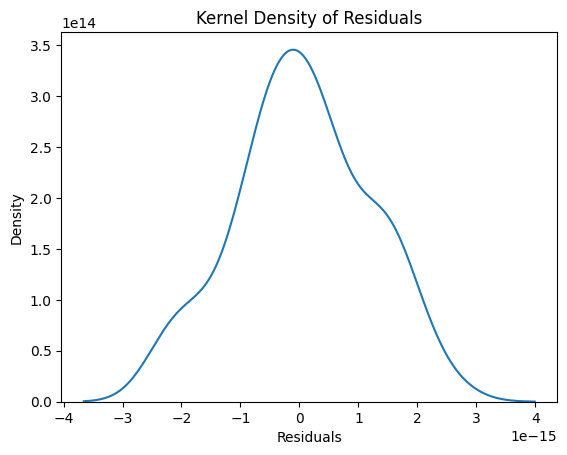

In [35]:
residuals = y - y_pred

sns.kdeplot(residuals)
plt.title("Kernel Density of Residuals")
plt.xlabel("Residuals")
plt.show()

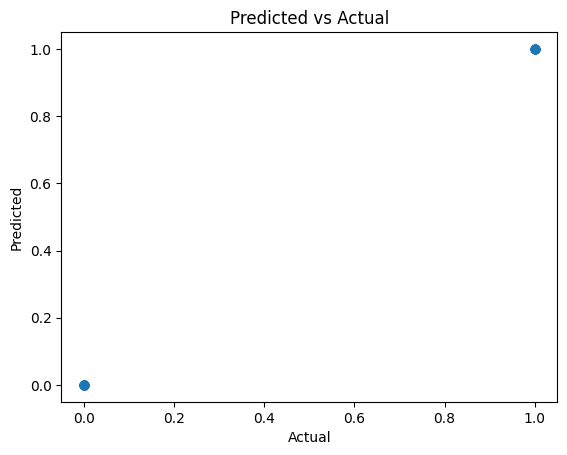

In [36]:
plt.scatter(y, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

In [37]:
model = LinearRegression()

cv_mse = -cross_val_score(model, X, y,
                          scoring='neg_mean_squared_error',
                          cv=5)

print("CV MSE for each fold:", cv_mse)
print("Mean CV MSE:", np.mean(cv_mse))

CV MSE for each fold: [0.04872133 0.07295289 0.04721866 0.04686773 0.08485489]
Mean CV MSE: 0.06012309872062149


The training the mean squared error is very close to zero, indicating a near-perfect fit to the training data. However, the cross-validated mean squared error is approximately 0.06, which is much larger than the training MSE. This indicates that the model does not generalize well to new data. From the bias-variance tradeoff perspective, the model has very low bias but high variance. The large number of predictors relative to the number of observations leads to overfitting, which leads to poor performance on new data.

In [39]:
lasso_cv = LassoCV(cv=5, random_state=0, max_iter=10000)
lasso_cv.fit(X, y)

y_pred_lasso = lasso_cv.predict(X)

coef = pd.Series(lasso_cv.coef_, index=X.columns)

selected_genes = coef[coef != 0]

discarded_genes = coef[coef == 0]

print("Number of selected genes:", len(selected_genes))
print("Number of discarded genes:", len(discarded_genes))
print("\nSelected genes:")
print(selected_genes.sort_values(key=abs, ascending=False))

Number of selected genes: 34
Number of discarded genes: 7095

Selected genes:
M63138_at           1.294145e-05
M19507_at           1.150747e-05
U05255_s_at         1.146583e-05
M27891_at           1.000528e-05
X17042_at           8.734762e-06
Y00787_s_at         5.454046e-06
M96326_rna1_at      3.045484e-06
M17733_at          -3.027364e-06
J04164_at          -2.975928e-06
M91036_rna1_at      2.704303e-06
X78992_at           2.598685e-06
L06797_s_at        -2.527830e-06
M26602_at          -2.373871e-06
HG3549-HT3751_at   -1.866398e-06
M14328_s_at         1.777423e-06
M14483_rna1_s_at   -1.758451e-06
V00594_s_at        -1.685259e-06
U14968_at           1.377602e-06
Z70759_at           1.289107e-06
X57351_s_at        -1.190599e-06
M11722_at          -1.175811e-06
M33680_at          -1.070980e-06
M11147_at           9.651806e-07
L38941_at           9.359366e-07
HG2887-HT3031_at   -8.149813e-07
X03689_s_at        -7.578508e-07
M26708_s_at        -7.132857e-07
M77232_rna1_at      4.205801e-0

A good handful of genes were selected (34). Majority of the genes were discareded (7095). This removes any noisy or irrelvant genes and allows for the model to be better fit

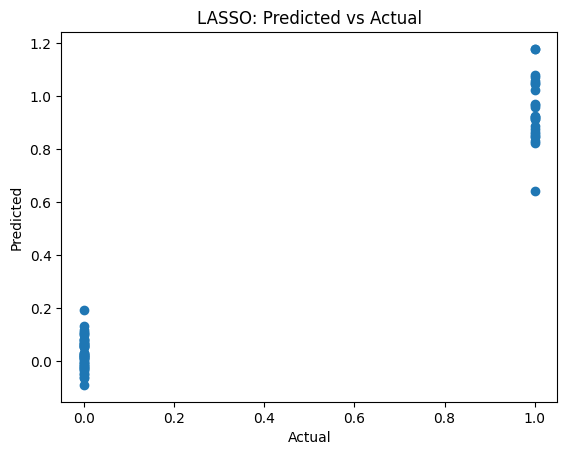

In [40]:
plt.scatter(y, y_pred_lasso)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("LASSO: Predicted vs Actual")
plt.show()

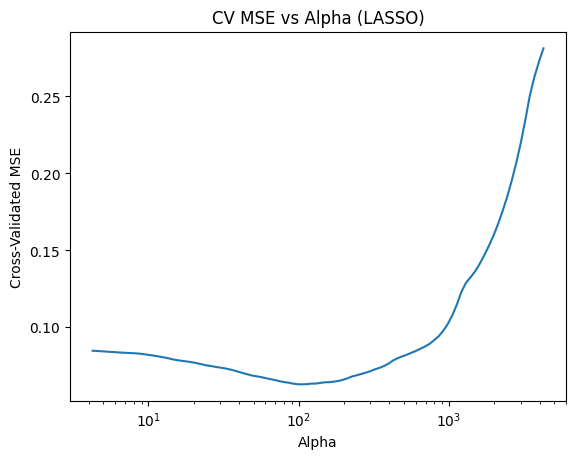

In [41]:
mean_mse = np.mean(lasso_cv.mse_path_, axis=1)

plt.plot(lasso_cv.alphas_, mean_mse)
plt.xscale('log')  # IMPORTANT
plt.xlabel("Alpha")
plt.ylabel("Cross-Validated MSE")
plt.title("CV MSE vs Alpha (LASSO)")
plt.show()

In [42]:
print("Optimal alpha:", lasso_cv.alpha_)

Optimal alpha: 105.24436668425457


The plot creates a U-shaped curve. For alpha values between 1 and about 100, the LASSO is overfitting. An alpha value a little above 100, LASSO is a better fit with the optimal alpha around 105. Then, as alpha increases, the LASSO becomes underfitting. Overall, small alpha is overfitting and a big alpha is underfitting.a

6.

Linear regression performs perfectly on the training set because the number of predictors greatly exceeds the number of observations, which allows the model to fit the data exactly and get near-zero training error. However, this can lead to overfitting, where the model captures noise rather than true underlying patterns, resulting in poor performance on new data. In contrast, LASSO introduces a regularization penalty that shrinks many coefficients to zero, effectively selecting a smaller and more relevant subset of genes. This reduces model complexity and variance, which helps to prevent overfitting. LASSO may not fit the training data perfectly, but it performs better on new data.

7.

Regularization methods lend themsevles to precision health because these datasets typically have far more predictors than observations, such as thousands of genes, but relatively few patients. Ordinary regression models tend to overfit in these situations. Regularization techniques like LASSO control model complexity by shrinking coefficients, reducing variance, and improving generalization to new data. Additionally, methods like LASSO perform feature selection by setting many coefficients to zero, identifying a smaller set of important genes that may serve as interpretable biomarkers. It is crucial that precision health gets information about relevant/important genes and no noise with it.

8.

While LASSO is useful in such scenarios, it poses several risks in precision health applications. First, models may overfit small datasets and fail to generalize to new patients, leading to unreliable predictions. Second, important variables may be incorrectly shrunk to zero, leading to them being overlooked. Highly correlated predictors can also influence LASSO and produce inaccurate information. Finally, biases in the data may result in unequal performance across populations, raising concerns about fairness and patient safety. These risks highlight the need for careful validation and domain expertise when applying such methods in healthcare.